# 05 · Kohonen's animals: the classic semantic map on a sphere

Sixteen animals are described by 13 yes/no attributes: small, medium, big; two legs, four legs, hair, hooves,
mane, feathers; likes to hunt, run, fly, swim (Ritter & Kohonen 1989). Nothing tells the SOM which animals are
birds, hunters or grazers, yet the trained map puts them in those groups. Every neuron is labelled with the
animals it wins, so the groups can be read straight off the map.

Script version: [`examples/05_kohonen_animals.py`](../05_kohonen_animals.py) · Needs: numpy, mtgeodesicdome, matplotlib, ipywidgets
(optional: `ipympl` for live figures)

<sub>SPDX-License-Identifier: AGPL-3.0-or-later · Copyright (C) 2022-2026 Masahiro Takatsuka. See the NOTICE file for attribution terms.</sub>

## Set-up

In [1]:
import nb_setup  # makes mt.geodesicsom importable from a checkout; helpers for the controls below

WIDGET = nb_setup.setup()  # live figures with ipympl, static images otherwise

figures: live (ipympl) -- drag the maps, click neurons, use the buttons on the figures


In [2]:
import ipywidgets as widgets
import numpy as np

from mt.geodesicsom import datasets
from mt.geodesicsom.gui import explore
from mt.geodesicsom.gui.explorer import make_som

## 1. The data

In [3]:
x, animals, names = datasets.animals()
print(f'{"":8s}' + ' '.join(f'{n[:5]:>5s}' for n in names))
for animal, row in zip(animals, x, strict=True):
    print(f'{animal:8s}' + ' '.join(f'{"x" if v else ".":>5s}' for v in row))

        small mediu   big two_l four_  hair hoove  mane feath  hunt   run   fly  swim
dove        x     .     .     x     .     .     .     .     x     .     .     x     .
hen         x     .     .     x     .     .     .     .     x     .     .     .     .
duck        x     .     .     x     .     .     .     .     x     .     .     .     x
goose       x     .     .     x     .     .     .     .     x     .     .     x     x
owl         x     .     .     x     .     .     .     .     x     x     .     x     .
hawk        x     .     .     x     .     .     .     .     x     x     .     x     .
eagle       .     x     .     x     .     .     .     .     x     x     .     x     .
fox         .     x     .     .     x     x     .     .     .     x     .     .     .
dog         .     x     .     .     x     x     .     .     .     .     x     .     .
wolf        .     x     .     .     x     x     .     x     .     x     x     .     .
cat         x     .     .     .     x     x     .     

Owl and hawk have the same attributes, and so do horse and zebra, so each pair must share a neuron. The
attributes are already 0/1, so they are not standardised.

## 2. Train a small sphere

`GeodesicDome(4)` has 162 neurons, plenty for 16 animals.

In [4]:
som = make_som('sphere', frequency=4, seed=3)
som.initialise(dataset=x)
som.train(x, epochs=60)
print(f'{som}: QE {som.quantisation_error(x):.3f}, TE {som.topographic_error(x):.3f}')
for node, winners in enumerate(som.bmu_labels(x, animals, mode='all')):
    if winners:
        print(f'  neuron {node:4d}: {winners}')

GeodesicSOM(frequency=4, neurons=162, dim=13): QE 0.038, TE 0.000
  neuron    9: hawk/owl
  neuron   13: hen
  neuron   16: dove
  neuron   42: duck
  neuron   57: eagle
  neuron   62: goose
  neuron   67: cat
  neuron   68: tiger
  neuron  109: fox
  neuron  120: cow
  neuron  125: wolf
  neuron  127: lion
  neuron  130: horse/zebra
  neuron  147: dog


## 3. The semantic map

Each neuron is labelled with all the animals it wins. The view is turned so that the animals are in the middle of
the map.

> **Live or static?** With `ipympl` installed the viewers below are live: drag a sphere to rotate it, click a
> neuron to inspect it, and use the radio buttons, check boxes and keys on the figure itself. Without it they are
> images, and the controls under each viewer redraw them.

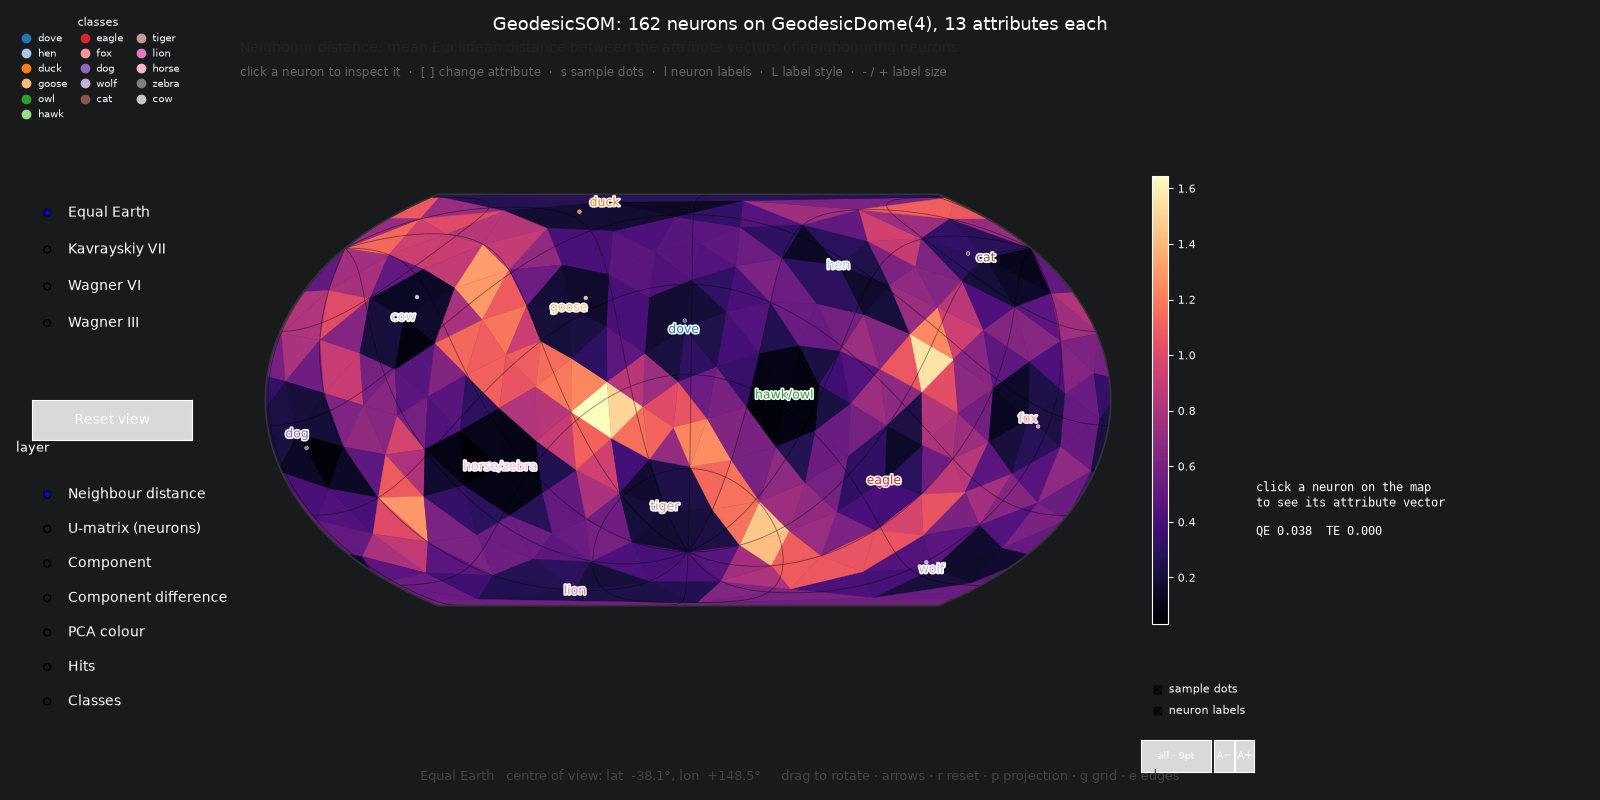

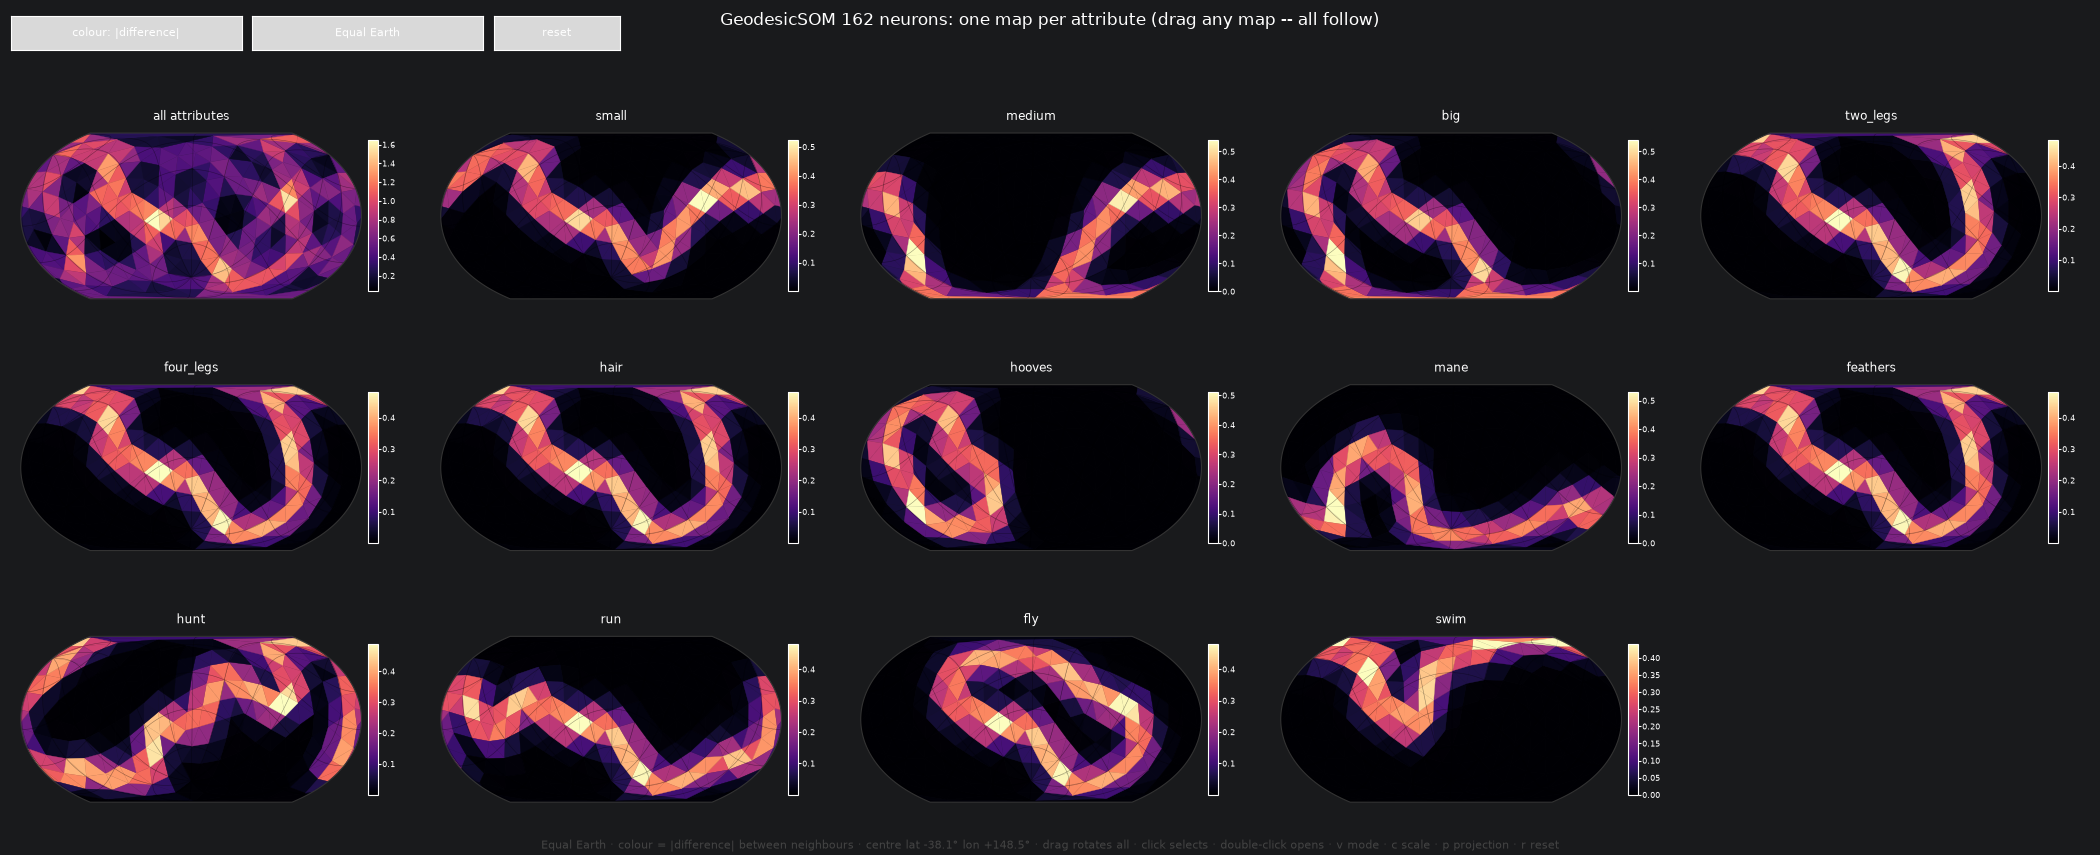

In [5]:
centre = som.points[som.bmu(x)].mean(axis=0)
view = (np.degrees(np.arcsin(centre[2] / np.linalg.norm(centre))), np.degrees(np.arctan2(centre[1], centre[0])))

views = explore(som, x, labels=animals, feature_names=names, node_labels='all', label_size=9, view=view,
                show=False)

In [6]:
nb_setup.controls(views.map, views.matrix)

Output()

The matrix shows *why*: look at where each attribute changes. *feathers* and *two legs* change exactly along the
bird/mammal border, *hooves* fences off horse, zebra and cow, and the size attributes cut across both groups.

## 4. Try it: the paper's set-up, or a flat map

* **symbols** sets the data up as in the paper: each attribute vector is scaled to unit length and a small
  "symbol" part (0.2 for the animal itself, 0 for the others) is added, so every animal is a different input and
  owl/hawk and horse/zebra separate.
* **lattice** `hexagonal` gives a flat 10 × 15 map, as in the paper.

In [7]:
@widgets.interact_manual(symbols=widgets.Checkbox(value=True, description='symbol part'),
                         lattice=widgets.ToggleButtons(options=['sphere', 'hexagonal', 'rectilinear']),
                         freq=widgets.IntSlider(value=4, min=2, max=10, description='sphere freq'),
                         epochs=widgets.IntSlider(value=60, min=5, max=200),
                         seed=widgets.IntSlider(value=3, min=0, max=20))
def animals_map(symbols, lattice, freq, epochs, seed):
    x, animals, names = datasets.animals(symbols=symbols)
    som = make_som(lattice, frequency=freq, rows=10, cols=15, seed=seed)
    som.initialise(dataset=x)
    som.train(x, epochs=epochs)
    print(f'{som}: QE {som.quantisation_error(x):.3f}, TE {som.topographic_error(x):.3f}')
    view = None
    if lattice == 'sphere':
        c = som.points[som.bmu(x)].mean(axis=0)
        view = (np.degrees(np.arcsin(c[2] / np.linalg.norm(c))), np.degrees(np.arctan2(c[1], c[0])))
    with nb_setup.building():        # with the symbol part the matrix would have 29 maps: map only
        views = explore(som, x, labels=animals, feature_names=names, node_labels='all', label_size=9,
                        matrix=not symbols, view=view, show=False)
    nb_setup.show(views.map)
    nb_setup.controls(views.map, *[v for v in [views.matrix] if v is not None])

interactive(children=(Checkbox(value=True, description='symbol part'), ToggleButtons(description='lattice', op…